# Australia 2025 F1 Telemetry Analysis

Comprehensive analysis of driver telemetry data from Australia 2025 qualifying and race.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up paths - use absolute path to project root
project_root = '/Users/ronithneelam/F1-Driver-Analysis'

# Load raw telemetry data
quali_path = os.path.join(project_root, 'data/raw_data/fastf1/australia_2025_telemetry_qualifying.csv')
race_path = os.path.join(project_root, 'data/raw_data/fastf1/australia_2025_telemetry_race.csv')

# Load processed data with acceleration/corners
quali_processed_path = os.path.join(project_root, 'data/processed/australia_2025_quali_telemetry_processed.csv')
corner_analysis_path = os.path.join(project_root, 'data/processed/australia_2025_quali_corner_analysis.csv')

# Load qualifying data (processed version with acceleration & corners)
try:
    quali_df = pd.read_csv(quali_processed_path)
    print("✓ Loaded processed qualifying data (with acceleration & corners)")
except FileNotFoundError:
    quali_df = pd.read_csv(quali_path)
    print("✓ Loaded raw qualifying data")

# Load race data if available
try:
    race_df = pd.read_csv(race_path)
    print("✓ Loaded race data")
except FileNotFoundError:
    race_df = None
    print("Note: Race data not available")

print(f"\nQualifying data loaded:")
print(f"  Shape: {quali_df.shape}")
print(f"  Columns: {quali_df.columns.tolist()}")
print(f"  Drivers: {quali_df['Driver'].nunique()}")

if race_df is not None:
    print(f"\nRace data loaded:")
    print(f"  Shape: {race_df.shape}")
    print(f"  Drivers: {race_df['Driver'].nunique()}")
else:
    print("\nRace data: Use raw race CSV for analysis")

✓ Loaded processed qualifying data (with acceleration & corners)
Note: Race data not available

Qualifying data loaded:
  Shape: (385496, 26)
  Columns: ['Year', 'Round', 'SessionType', 'DriverNumber', 'Driver', 'LapNumber', 'TimeInLap', 'Time', 'Throttle', 'Brake', 'DRS', 'RPM', 'Speed', 'X', 'Y', 'Z', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Compound', 'FreshTyre', 'Corner', 'Speed_ms', 'Acceleration', 'Accel_Type']
  Drivers: 20

Race data: Use raw race CSV for analysis


## Qualifying Analysis

In [12]:
# Best laps by driver in qualifying
# Convert LapTime to timedelta for proper comparison
quali_df_copy = quali_df.copy()
quali_df_copy['LapTime_td'] = pd.to_timedelta(quali_df_copy['LapTime'], errors='coerce')

# Get best lap for each driver
quali_best_laps = quali_df_copy.loc[quali_df_copy.groupby('Driver')['LapTime_td'].idxmin()]

# Convert to seconds for sorting
quali_best_laps['LapTime_seconds'] = quali_best_laps['LapTime_td'].dt.total_seconds()
quali_best_laps = quali_best_laps.sort_values('LapTime_seconds')

print("Qualifying - Top 10 Best Laps:")
print(quali_best_laps[['Driver', 'LapTime', 'LapTime_seconds']].head(10))

KeyError: '[nan] not in index'

In [ ]:
# Throttle and brake application analysis - Qualifying
quali_telemetry_stats = quali_df.groupby('Driver').agg({
    'Throttle': ['mean', 'max', 'min'],
    'Brake': ['mean', 'max'],
    'Speed': ['mean', 'max'],
    'RPM': ['mean', 'max']
}).round(2)

print("\nQualifying - Telemetry Statistics (All drivers):")
print(quali_telemetry_stats)

## Race Analysis

## Corner & Acceleration Analysis (Qualifying)

In [ ]:
# Load corner analysis
try:
    corner_df = pd.read_csv(corner_analysis_path)
    
    print("Corner Analysis - Deceleration & Acceleration Events")
    print("="*70)
    print(f"\nTotal corner events: {len(corner_df)}")
    print(f"Unique corners: {corner_df['Corner'].nunique()}")
    print(f"Drivers: {corner_df['Driver'].nunique()}")
    
    # Show highest deceleration events
    high_decel = corner_df.dropna(subset=['Max_Deceleration'])
    high_decel_sorted = high_decel.iloc[(high_decel['Max_Deceleration']*-1).argsort()[::-1]]
    
    print("\n\nHighest Deceleration Events:")
    print(high_decel_sorted[['Driver', 'Corner', 'Min_Speed', 'Max_Deceleration', 'Max_Acceleration_Exit']].head(15).to_string(index=False))
    
except Exception as e:
    print(f"Note: Corner analysis not available yet. {e}")

Corner Analysis - Deceleration & Acceleration Events

Total corner events: 59
Unique corners: 3
Drivers: 20


Highest Deceleration Events:
Driver    Corner  Min_Speed  Max_Deceleration  Max_Acceleration_Exit
   VER Turn 9-10 155.000000             -15.0               2.314817
   DOO Turn 9-10 114.000000             -15.0              10.416681
   VER    Turn 1   0.000000             -15.0               8.960624
   DOO   Turn 11 146.545449             -15.0               3.472229
   TSU Turn 9-10 204.558605             -15.0               1.157409
   LEC   Turn 11 219.958332             -15.0               2.777781
   NOR   Turn 11 112.000000             -15.0              10.912762
   OCO   Turn 11 146.000000             -15.0               1.736111
   PIA   Turn 11 108.000000             -15.0               4.649011
   HAM    Turn 1   0.000000             -15.0               8.680556
   ALO   Turn 11 196.000000             -15.0               4.187609
   ALO Turn 9-10 145.656254      

In [ ]:
# Corner data for a specific driver - Max Verstappen
driver = 'VER'

if 'Corner' in quali_df.columns and 'Acceleration' in quali_df.columns:
    driver_corners = quali_df[(quali_df['Driver'] == driver) & (quali_df['Corner'].notna())]
    
    if len(driver_corners) > 0:
        print(f"\n{driver} - Acceleration/Deceleration at Corners")
        print("="*70)
        
        # Get corners
        for corner in sorted(driver_corners['Corner'].unique()):
            corner_data = driver_corners[driver_corners['Corner'] == corner]
            
            print(f"\n{corner}:")
            print(f"  Data points: {len(corner_data)}")
            print(f"  Min speed: {corner_data['Speed'].min():.1f} km/h")
            print(f"  Max speed: {corner_data['Speed'].max():.1f} km/h")
            print(f"  Max deceleration: {corner_data['Acceleration'].min():.2f} m/s²")
            print(f"  Max acceleration: {corner_data['Acceleration'].max():.2f} m/s²")
            print(f"  Avg throttle: {corner_data['Throttle'].mean():.1f}%")
            print(f"  Avg brake: {corner_data['Brake'].mean():.1f}%")
            
            # Show sample telemetry
            sample = corner_data[['TimeInLap', 'Speed', 'Throttle', 'Brake', 'Acceleration', 'Accel_Type']].head(5)
            print(f"\n  Sample telemetry:")
            print(sample.to_string(index=False))
    else:
        print("Corner data not yet processed. Run process_telemetry.py first.")
else:
    print("Acceleration and Corner columns not found. Load processed data.")


VER - Acceleration/Deceleration at Corners

Turn 1:
  Data points: 12994
  Min speed: 0.0 km/h
  Max speed: 317.6 km/h
  Max deceleration: -15.00 m/s²
  Max acceleration: 8.96 m/s²
  Avg throttle: 18.4%
  Avg brake: 0.2%

  Sample telemetry:
 TimeInLap      Speed  Throttle  Brake  Acceleration   Accel_Type
    95.627 303.000000     100.0  False      2.324501 Acceleration
    95.729 304.457145     100.0  False      3.968259 Acceleration
    95.907 307.000000     100.0  False      3.968251 Acceleration
    96.129 309.378573     100.0  False      2.976192 Acceleration
    96.187 310.000000     100.0  False      2.976184 Acceleration

Turn 11:
  Data points: 113
  Min speed: 191.9 km/h
  Max speed: 333.0 km/h
  Max deceleration: -11.57 m/s²
  Max acceleration: 2.98 m/s²
  Avg throttle: 62.4%
  Avg brake: 0.1%

  Sample telemetry:
 TimeInLap      Speed  Throttle  Brake  Acceleration   Accel_Type
    58.307 267.000000     100.0  False      1.736111 Acceleration
    58.449 268.014287     100

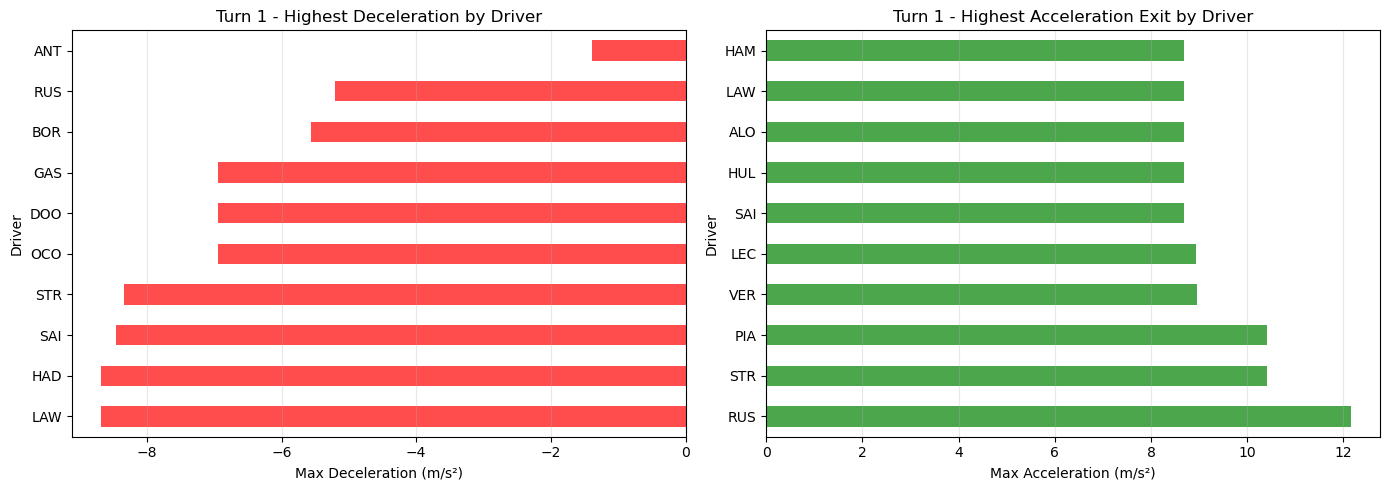

Chart shows acceleration/deceleration profiles at Turn 1 for qualifying


In [ ]:
# Visualization: Acceleration profiles by driver at Turn 1
if 'Corner' in quali_df.columns and 'Acceleration' in quali_df.columns:
    turn1_data = quali_df[quali_df['Corner'] == 'Turn 1'].copy()
    
    if len(turn1_data) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Deceleration into corner
        ax1 = axes[0]
        decel_data = turn1_data[turn1_data['Accel_Type'] == 'Deceleration'].groupby('Driver')['Acceleration'].min()
        decel_data.sort_values().tail(10).plot(kind='barh', ax=ax1, color='red', alpha=0.7)
        ax1.set_xlabel('Max Deceleration (m/s²)')
        ax1.set_title('Turn 1 - Highest Deceleration by Driver')
        ax1.grid(axis='x', alpha=0.3)
        
        # Acceleration exiting corner
        ax2 = axes[1]
        accel_data = turn1_data[turn1_data['Accel_Type'] == 'Acceleration'].groupby('Driver')['Acceleration'].max()
        accel_data.sort_values(ascending=False).head(10).plot(kind='barh', ax=ax2, color='green', alpha=0.7)
        ax2.set_xlabel('Max Acceleration (m/s²)')
        ax2.set_title('Turn 1 - Highest Acceleration Exit by Driver')
        ax2.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("Chart shows acceleration/deceleration profiles at Turn 1 for qualifying")

In [ ]:
# Race telemetry statistics
race_telemetry_stats = race_df.groupby('Driver').agg({
    'Throttle': ['mean', 'max'],
    'Brake': ['mean', 'max'],
    'Speed': ['mean', 'max'],
    'RPM': ['mean', 'max'],
    'LapNumber': 'max'  # Total laps completed
}).round(2)

print("Race - Telemetry Statistics:")
print(race_telemetry_stats)

In [ ]:
# Single driver deep dive - Max Verstappen
ver_race = race_df[race_df['Driver'] == 'VER']

print(f"Max Verstappen - Race Performance:")
print(f"  Total telemetry points: {len(ver_race):,}")
print(f"  Laps completed: {ver_race['LapNumber'].max()}")
print(f"  Avg throttle: {ver_race['Throttle'].mean():.2f}%")
print(f"  Max throttle: {ver_race['Throttle'].max():.2f}%")
print(f"  Avg brake: {ver_race['Brake'].mean():.2f}%")
print(f"  Max brake: {ver_race['Brake'].max():.2f}%")
print(f"  Avg speed: {ver_race['Speed'].mean():.2f} km/h")
print(f"  Max speed: {ver_race['Speed'].max():.2f} km/h")

## Data Exploration

In [ ]:
# Check data structure
print("Qualifying data columns:")
print(quali_df.columns.tolist())
print(f"\nData types:")
print(quali_df.dtypes)

In [ ]:
# Sample data view
print("Sample qualifying data:")
print(quali_df[quali_df['Driver'] == 'VER'].head(10)[['Driver', 'LapNumber', 'TimeInLap', 'Speed', 'Throttle', 'Brake', 'X', 'Y', 'Z']])